In [1]:
import os
PROXY_URL = "http://127.0.0.1:23897"

os.environ["HTTP_PROXY"] = PROXY_URL
os.environ["HTTPS_PROXY"] = PROXY_URL
os.environ["http_proxy"] = PROXY_URL
os.environ["https_proxy"] = PROXY_URL

os.environ["HF_ENDPOINT"] = "https://huggingface.co"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"

print("代理地址：", PROXY_URL)
print("Hugging Face 地址：", os.environ["HF_ENDPOINT"])
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel


print("PyTorch 版本：", torch.__version__)
print("CUDA 是否可用：", torch.cuda.is_available())

代理地址： http://127.0.0.1:23897
Hugging Face 地址： https://huggingface.co
PyTorch 版本： 2.9.0
CUDA 是否可用： True


In [2]:
DATA_DIR=Path("/workspace/E-DAIC/original_data")
SPLIT_DIR=Path("/workspace/E-DAIC/splits")
LABEL_DIR=Path("/workspace/E-DAIC/others")

TRAIN_SPLIT_FILE=SPLIT_DIR/"train_split.csv"
DEV_SPLIT_FILE=SPLIT_DIR/"dev_split.csv"
DETAIL_LABEL_FILE=LABEL_DIR/"Detailed_PHQ8_Labels.csv"

print("访谈数据目录：", DATA_DIR.is_dir())
print("训练划分文件：", TRAIN_SPLIT_FILE.is_file())
print("验证划分文件：", DEV_SPLIT_FILE.is_file())
print("详细标签文件：", DETAIL_LABEL_FILE.is_file())

访谈数据目录： True
训练划分文件： True
验证划分文件： True
详细标签文件： True


In [3]:
train_split_df=pd.read_csv(TRAIN_SPLIT_FILE)
dev_split_df=pd.read_csv(DEV_SPLIT_FILE)
labels_df=pd.read_csv(DETAIL_LABEL_FILE)

print(f"train_shape:{train_split_df.shape}\n"
      f"dev_shape:{dev_split_df.shape}\n"
      f"label_shape:{labels_df.shape}")

print(f"train_columns:{train_split_df.columns.to_list()}\n"
      f"label_columns:{labels_df.columns.tolist()}")

display(train_split_df.head())
display(labels_df.head())

train_shape:(163, 6)
dev_shape:(55, 6)
label_shape:(219, 10)
train_columns:['Participant_ID', 'Gender', 'PHQ_Binary', 'PHQ_Score', 'PCL-C (PTSD)', 'PTSD Severity']
label_columns:['Participant_ID', 'PHQ_8NoInterest', 'PHQ_8Depressed', 'PHQ_8Sleep', 'PHQ_8Tired', 'PHQ_8Appetite', 'PHQ_8Failure', 'PHQ_8Concentrating', 'PHQ_8Moving', 'PHQ_8Total']


,Participant_ID,Gender,PHQ_Binary,PHQ_Score,PCL-C (PTSD),PTSD Severity
0,302,male,0,4,0,28
1,303,female,0,0,0,17
2,304,female,0,6,0,20
3,305,male,0,7,0,28
4,307,female,0,4,0,23


,Participant_ID,PHQ_8NoInterest,PHQ_8Depressed,PHQ_8Sleep,PHQ_8Tired,PHQ_8Appetite,PHQ_8Failure,PHQ_8Concentrating,PHQ_8Moving,PHQ_8Total
0,300,0,0,1,0,1,0,0,0,2
1,301,0,0,1,1,1,0,0,0,3
2,302,1,1,0,1,0,1,0,0,4
3,303,0,0,0,0,0,0,0,0,0
4,304,0,1,1,2,2,0,0,0,6


In [4]:
QUESTION_COLUMNS = [
    "PHQ_8NoInterest",
    "PHQ_8Depressed",
    "PHQ_8Sleep",
    "PHQ_8Tired",
    "PHQ_8Appetite",
    "PHQ_8Failure",
    "PHQ_8Concentrating",
    "PHQ_8Moving",
]
QUESTION_NUMBER=1
question_column=QUESTION_COLUMNS[QUESTION_NUMBER-1]

participant_id=int(train_split_df["Participant_ID"].iloc[0])
transcript_file=(
    DATA_DIR
    / f"{participant_id}_P"
    / f"{participant_id}_Transcript.csv"
)
transcript_df=pd.read_csv(transcript_file)

mathed_label=labels_df.loc[labels_df["Participant_ID"]==participant_id
                           ,question_column]
score=int(mathed_label.iloc[0])
print(type(mathed_label))
print("当前题目：", question_column)
print("参与者编号：", participant_id)
print("转录文件：", transcript_file)
print("转录表形状：", transcript_df.shape)
print("转录表列名：", transcript_df.columns.tolist())
print("该参与者的题目得分：", score)

display(transcript_df.head())

<class 'pandas.core.series.Series'>
当前题目： PHQ_8NoInterest
参与者编号： 302
转录文件： /workspace/E-DAIC/original_data/302_P/302_Transcript.csv
转录表形状： (99, 4)
转录表列名： ['Start_Time', 'End_Time', 'Text', 'Confidence']
该参与者的题目得分： 1


,Start_Time,End_Time,Text,Confidence
0,2.1,3.2,just move around a little bit,0.906568
1,26.3,27.1,when you're finished,0.793796
2,58.2,59.1,how are you doing today,0.859790
3,59.6,61.0,I'm fine how about yourself,0.987629
4,66.6,67.3,where you from,0.911304


In [5]:
text_list=(
    transcript_df["Text"]
    .dropna()
    .astype(str)
    .tolist()
)
print("有效文本数量：", len(text_list))
print("text_list 的类型：", type(text_list))
print("第一句话的类型：", type(text_list[0]))
for number, text in enumerate(text_list[:5],start=1):
    print(f"{number},{text}")

有效文本数量： 99
text_list 的类型： <class 'list'>
第一句话的类型： <class 'str'>
1,just move around a little bit
2, when you're finished
3, how are you doing today
4, I'm fine how about yourself
5, where you from


In [6]:
MODEL_NAME="sentence-transformers/all-distilroberta-v1"

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)

encoded_example=tokenizer(text_list[0],return_tensors="pt")

print(f"encoded_example:{encoded_example}")

input_ids=encoded_example["input_ids"]
attention_mask=encoded_example["attention_mask"]

tokens=tokenizer.convert_ids_to_tokens(input_ids[0])

print("tokenizer 类型：", type(tokenizer))
print("原始文本：", text_list[0])
print("tokens：", tokens)
print("input_ids：", input_ids)
print("input_ids 形状：", input_ids.shape)
print("attention_mask：", attention_mask)


encoded_example:{'input_ids': tensor([[   0, 8987,  517,  198,   10,  410,  828,    2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}
tokenizer 类型： <class 'transformers.models.roberta.tokenization_roberta.RobertaTokenizer'>
原始文本： just move around a little bit
tokens： ['<s>', 'just', 'Ġmove', 'Ġaround', 'Ġa', 'Ġlittle', 'Ġbit', '</s>']
input_ids： tensor([[   0, 8987,  517,  198,   10,  410,  828,    2]])
input_ids 形状： torch.Size([1, 8])
attention_mask： tensor([[1, 1, 1, 1, 1, 1, 1, 1]])


In [11]:
encoded_input=tokenizer(
    text_list,
    padding=True,
    truncation=True,
    return_tensors="pt"
)
print(encoded_input["attention_mask"])

token_counts=encoded_input["attention_mask"].sum(dim=1)

shortest_index=torch.argmin(token_counts).item()
longest_index=torch.argmax(token_counts).item()
print(token_counts)
print(f"input_ids shape:{encoded_input["input_ids"].shape}\n"
      f"attention_mask shape:{encoded_input["attention_mask"].shape}")

print(f"最短token数:{token_counts[shortest_index].item()}\n"
      f"shortest sentense:{text_list[shortest_index]}")

print("最长句 token 数：", token_counts[longest_index].item())
print("最长句：", text_list[longest_index])

print(f"padding's token sum:{(encoded_input["attention_mask"]==0).sum().item()}")

tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])
tensor([ 8,  6,  7,  8,  5,  6,  4,  3,  8, 12,  5, 15, 10, 27,  5, 11, 18,  5,
         5, 18, 17,  3, 26,  3,  6,  7,  7, 28,  5,  5,  5,  5,  8,  6,  6,  4,
        19,  8, 10,  9,  5,  3,  7, 11, 11, 11, 12,  4, 22,  6,  8,  3,  4, 14,
         4,  6,  5,  6,  6, 10,  5,  5, 12,  3,  8,  5, 16,  4,  4,  5,  3, 21,
         8,  4,  6, 12,  3,  8,  9,  4,  3,  6,  9, 10,  8,  5, 19,  7,  4,  6,
        10, 24, 18,  7,  4,  4,  5,  5,  7])
input_ids shape:torch.Size([99, 28])
attention_mask shape:torch.Size([99, 28])
最短token数:3
shortest sentense: okay
最长句 token 数： 28
最长句：  kind of mad cuz I have set aside some time to spend with him and he just blew it off and then call me back
padding's token sum:1935


### 加载预训练模型并生成词向量

In [8]:
import huggingface_hub.constants as hf_constants
import os



hf_constants.HF_HUB_DOWNLOAD_TIMEOUT = 300
hf_constants.HF_HUB_ETAG_TIMEOUT = 60

print("下载超时时间已调整")


if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")
print(f"device={device}")


embedder=AutoModel.from_pretrained(MODEL_NAME)
embedder=embedder.to(device)
embedder.eval()

encoded_on_device=encoded_input.to(device)

with torch.no_grad():
    model_output=embedder(**encoded_on_device)

token_embeddings=model_output[0]

print("模型类型：", type(embedder))
print("模型输出类型：", type(model_output))
print("词向量形状：", token_embeddings.shape)
print("词向量所在设备：", token_embeddings.device)


下载超时时间已调整
device=cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-distilroberta-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型类型： <class 'transformers.models.roberta.modeling_roberta.RobertaModel'>
模型输出类型： <class 'transformers.modeling_outputs.BaseModelOutputWithPoolingAndCrossAttentions'>
词向量形状： torch.Size([99, 28, 768])
词向量所在设备： cuda:0


In [9]:
print(model_output[1])

tensor([[ 0.0047,  0.0922, -0.3482,  ..., -0.1540, -0.0726,  0.0814],
        [-0.1928,  0.1383, -0.2709,  ...,  0.1126, -0.0013, -0.1954],
        [ 0.0423,  0.0557, -0.0369,  ..., -0.1339,  0.0372,  0.1758],
        ...,
        [-0.2238, -0.0667, -0.0068,  ..., -0.1609, -0.1223,  0.2886],
        [ 0.0537, -0.0366,  0.1017,  ..., -0.2285,  0.1503, -0.0169],
        [-0.0120, -0.1050, -0.1705,  ..., -0.0526, -0.0363, -0.0756]],
       device='cuda:0')


In [10]:
def mean_pooling(model_output,attention_mask):
    token_embeddings=model_output["last_hidden_state"]
    input_mask_expanded=(
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )
    embedding_sum=torch.sum(
        token_embeddings*input_mask_expanded,dim=1
    )
    valid_token_count=torch.clamp(
        input_mask_expanded.sum(dim=1)
        ,min=1e-9
    )
    sentence_embeddings=embedding_sum / valid_token_count

    return sentence_embeddings

sentence_embeddings=mean_pooling(
    model_output,
    encoded_on_device["attention_mask"],   
)
print("池化前形状：", token_embeddings.shape)
print("池化后形状：", sentence_embeddings.shape)
print("句向量所在设备：", sentence_embeddings.device)
print("第一句话向量的前 5 个数：", sentence_embeddings[0, :5])



池化前形状： torch.Size([99, 28, 768])
池化后形状： torch.Size([99, 768])
句向量所在设备： cuda:0
第一句话向量的前 5 个数： tensor([ 0.0714, -0.2326,  0.6676,  0.6544, -0.0883], device='cuda:0')


In [11]:
toy_embeddings = torch.tensor([
    [
        [1.0, 2.0],
        [3.0, 4.0],
        [5.0, 6.0],
        [7.0, 8.0],
    ]
]) #1 4 2

toy_mask = torch.tensor([
    [1, 1, 1, 0]
])

toy_mask_expanded = (
    toy_mask
    .unsqueeze(-1)
    .expand(toy_embeddings.size())
    .float()
)

toy_masked_embeddings = toy_embeddings * toy_mask_expanded
toy_embedding_sum = toy_masked_embeddings.sum(dim=1)
toy_valid_count = toy_mask_expanded.sum(dim=1)
toy_mean = toy_embedding_sum / toy_valid_count
print("原始向量：\n", toy_embeddings)
print("扩展后的 mask：\n", toy_mask_expanded)
print("屏蔽 padding 后：\n", toy_masked_embeddings)
print("向量求和：\n", toy_embedding_sum)
print("有效 token 数：\n", toy_valid_count)
print("平均结果：\n", toy_mean)

原始向量：
 tensor([[[1., 2.],
         [3., 4.],
         [5., 6.],
         [7., 8.]]])
扩展后的 mask：
 tensor([[[1., 1.],
         [1., 1.],
         [1., 1.],
         [0., 0.]]])
屏蔽 padding 后：
 tensor([[[1., 2.],
         [3., 4.],
         [5., 6.],
         [0., 0.]]])
向量求和：
 tensor([[ 9., 12.]])
有效 token 数：
 tensor([[3., 3.]])
平均结果：
 tensor([[3., 4.]])


In [12]:
MAX_TURNS=120
EMBEDDING_DIM=768

sentence_embeddings_unpadded=mean_pooling(model_output,
                                          encoded_on_device["attention_mask"])

turn_count=len(text_list)

if turn_count>MAX_TURNS:
    turn_count=MAX_TURNS

sentence_embeddings_fixed=sentence_embeddings_unpadded[:turn_count]

turn_padding_mask=torch.tensor([False]*turn_count)

if turn_count < MAX_TURNS:
    padding_count=MAX_TURNS-turn_count

    zero_padding=torch.zeros(
        padding_count,EMBEDDING_DIM,device=device,
    )

    sentence_embeddings_fixed=torch.cat(
        (
            sentence_embeddings_fixed,
            zero_padding,
        ),
        dim=0
    )

    padding_part=torch.tensor(
        [True]*padding_count
    )
    turn_padding_mask=torch.cat(
        (
            turn_padding_mask,
            padding_part
        ),
        dim=0
    )

print("原始句向量形状：",
      sentence_embeddings_unpadded.shape)

print("固定长度后的形状：",
      sentence_embeddings_fixed.shape)

print("对话 mask 形状：",
      turn_padding_mask.shape)

print("真实对话轮数：", turn_count)
print("补齐轮数：", turn_padding_mask.sum().item())

print("第 98 行是否为 padding：",
      turn_padding_mask[98].item())

print("第 99 行是否为 padding：",
      turn_padding_mask[99].item())


原始句向量形状： torch.Size([99, 768])
固定长度后的形状： torch.Size([120, 768])
对话 mask 形状： torch.Size([120])
真实对话轮数： 99
补齐轮数： 21
第 98 行是否为 padding： False
第 99 行是否为 padding： True


### 对每个句向量进行 L2 归一化

In [13]:
norms_before=torch.linalg.vector_norm(
    sentence_embeddings_fixed,
    ord=2,
    dim=1,
)

sentence_embeddings_normalized=F.normalize(
    sentence_embeddings_fixed,
    p=2,
    dim=1,
)

norms_after=torch.linalg.vector_norm(
    sentence_embeddings_normalized,
    ord=2,
    dim=1
)
print("归一化前形状：",
      sentence_embeddings_fixed.shape)
print("归一化后形状：",
      sentence_embeddings_normalized.shape)

print("第 0 句话归一化前的长度：",
      norms_before[0].item())
print("第 0 句话归一化后的长度：",
      norms_after[0].item())

print("最后一个真实句子归一化后的长度：",
      norms_after[98].item())
print("第一个 padding 归一化后的长度：",
      norms_after[99].item())

归一化前形状： torch.Size([120, 768])
归一化后形状： torch.Size([120, 768])
第 0 句话归一化前的长度： 10.800110816955566
第 0 句话归一化后的长度： 1.0
最后一个真实句子归一化后的长度： 0.9999999403953552
第一个 padding 归一化后的长度： 0.0


### 封装完整预处理函数

In [14]:
def preprocess_texts(txt_list):
    selected_texts=txt_list[:MAX_TURNS]
    turn_count=len(selected_texts)

    encoded_input=tokenizer(
        selected_texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        model_output=embedder(**encoded_input)

    sentence_embeddings=mean_pooling(model_output,encoded_input["attention_mask"])

    padding_count=MAX_TURNS-turn_count

    if padding_count>0:
        zero_padding=torch.zeros(
            padding_count,
            EMBEDDING_DIM,
            device=device
        )

        sentence_embeddings=torch.cat(
            (
                sentence_embeddings,
                zero_padding
            ),
            dim=0
        )

    turn_padding_mask=torch.tensor([False]*turn_count+[True]*padding_count,dtype=bool)
    sentence_embeddings=F.normalize(
        sentence_embeddings,
        p=2,
        dim=1
    )
    return (
        sentence_embeddings.detach().cpu(),
        turn_padding_mask
    )

In [15]:
test_embeddings, test_mask = preprocess_texts(text_list)

print("预处理结果形状：", test_embeddings.shape)
print("mask 形状：", test_mask.shape)
print("句向量设备：", test_embeddings.device)
print("句向量数据类型：", test_embeddings.dtype)
print("mask 数据类型：", test_mask.dtype)
print("真实轮数：", (~test_mask).sum().item())
print("padding 轮数：", test_mask.sum().item())

预处理结果形状： torch.Size([120, 768])
mask 形状： torch.Size([120])
句向量设备： cpu
句向量数据类型： torch.float32
mask 数据类型： torch.bool
真实轮数： 99
padding 轮数： 21


### 定义 Dataset 类

In [16]:
class EDAICTextDataset(Dataset):
    def __init__(
            self,
            split,
            data_dir,
            split_dir,
            label_dir,
            question_number,
            missing_files=None,
    ):
        super().__init__()
        if split=="train":
            split_file=split_dir / "train_split.csv"
        elif split=="val":
            split_file=split_dir / "dev_split.csv"
        else:
            raise ValueError(f"split only is train or dev, not:{split}")

        if question_number<1 or question_number>8:
            raise ValueError(f"quesion number must bettwen 1 and 8")

        if missing_files is None:
            missing_files=[]

        missing_files=set(missing_files)

        split_df=pd.read_csv(split_file)
        labels_df=pd.read_csv(label_dir/"Detailed_PHQ8_Labels.csv")

        question_column=QUESTION_COLUMNS[question_number-1]

        participant_ids=(
            split_df["Participant_ID"].astype(int).tolist()
        )

        self.data=[]
        self.participant_ids=[]

        for participant_id in participant_ids:
            if participant_id in missing_files:
                continue

            transcript_file=data_dir/f"{participant_id}_P"/f"{participant_id}_Transcript.csv"

            if not transcript_file.is_file():
                print(f"Warning: step over missing file{transcript_file}")
                continue

            transcript_df=pd.read_csv(transcript_file)
            text_list=transcript_df["Text"].dropna().astype(str).tolist()

            matched_label=labels_df.loc[labels_df["Participant_ID"]==participant_id,question_column]

            if matched_label.empty:
                raise ValueError(f"cannot found {participant_id}'s label")
            score=int(matched_label.iloc[0])

            self.data.append((text_list,score))
            self.participant_ids.append(participant_id)
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text_list,score=self.data[index]

        embeddings,mask=preprocess_texts(text_list)
        label=torch.tensor(score,dtype=torch.long)
        return embeddings,mask,label

### 创建训练数据集

In [17]:
train_dataset=EDAICTextDataset(
    split="train",
    data_dir=DATA_DIR,
    split_dir=SPLIT_DIR,
    label_dir=LABEL_DIR,
    question_number=QUESTION_NUMBER
)
print("训练样本数：", len(train_dataset))
print(
    "第一个参与者：",
    train_dataset.participant_ids[0],
)

训练样本数： 163
第一个参与者： 302


In [18]:
sample_embeddings,sample_mask,sample_label=(train_dataset[0])

print("句向量形状：", sample_embeddings.shape)
print("mask 形状：", sample_mask.shape)
print("标签形状：", sample_label.shape)
print("标签类型：", sample_label.dtype)
print("标签值：", sample_label.item())

句向量形状： torch.Size([120, 768])
mask 形状： torch.Size([120])
标签形状： torch.Size([])
标签类型： torch.int64
标签值： 1


In [19]:
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
SEED=42
set_seed(SEED)



In [20]:
loader_generator=torch.Generator().manual_seed(SEED)
train_loader=DataLoader(train_dataset,batch_size=10,shuffle=True,num_workers=0,generator=loader_generator)

print("训练样本数：", len(train_dataset))
print("训练批次数：", len(train_loader))

训练样本数： 163
训练批次数： 17


In [21]:
first_batch=next(iter(train_loader))
batch_embeddings,batch_masks,batch_labels=first_batch
print("批次句向量形状：", batch_embeddings.shape)
print("批次 mask 形状：", batch_masks.shape)
print("批次标签形状：", batch_labels.shape)

print("句向量类型：", batch_embeddings.dtype)
print("mask 类型：", batch_masks.dtype)
print("标签类型：", batch_labels.dtype)

print("当前批次标签：", batch_labels)

批次句向量形状： torch.Size([10, 120, 768])
批次 mask 形状： torch.Size([10, 120])
批次标签形状： torch.Size([10])
句向量类型： torch.float32
mask 类型： torch.bool
标签类型： torch.int64
当前批次标签： tensor([1, 0, 1, 0, 0, 0, 0, 0, 0, 1])


### 手写一个 LSTM 时间步

In [22]:
torch.manual_seed(42)

TOY_INPUT_SIZE=3
TOY_HIDDEN_SIZE=2

x_t=torch.tensor([0.5,-0.2,0.1],dtype=torch.float32)
h_prev=torch.tensor([0.0,0.0],dtype=torch.float32)
c_prev=torch.tensor([0.0,0.0],dtype=torch.float32)

W_f=torch.randn(TOY_HIDDEN_SIZE,TOY_INPUT_SIZE+TOY_HIDDEN_SIZE)*0.2
b_f=torch.zeros(TOY_HIDDEN_SIZE)

W_i=torch.randn(TOY_HIDDEN_SIZE,TOY_INPUT_SIZE+TOY_HIDDEN_SIZE)*0.2
b_i=torch.zeros(TOY_HIDDEN_SIZE)

W_g=torch.randn(TOY_HIDDEN_SIZE,TOY_INPUT_SIZE+TOY_HIDDEN_SIZE)*0.2
b_g=torch.zeros(TOY_HIDDEN_SIZE)

W_o=torch.randn(TOY_HIDDEN_SIZE,TOY_INPUT_SIZE+TOY_HIDDEN_SIZE)*0.2
b_o=torch.zeros(TOY_HIDDEN_SIZE)

def manual_lstm_step(x_t,h_prev,c_prev):
    combined=torch.cat(
        (x_t,h_prev),
        dim=0
    )
    f_t=torch.sigmoid(W_f@combined+b_f)
    i_t=torch.sigmoid(W_i@combined+b_i)
    g_t=torch.tanh(W_g@combined+b_g)
    o_t=torch.sigmoid(W_o@combined+b_o)
    #新记忆 = 遗忘门×旧记忆 + 输入门×候选记忆
    c_t=f_t*c_prev + i_t*g_t
    h_t=o_t * torch.tanh(c_t)
    # c_t：内部长期记忆。
    # tanh(c_t)：把记忆压缩到 -1～1。
    # o_t：决定其中多少内容对外输出。
    # h_t：传给下一时间步，同时也是当前时间步的输出。

    return h_t,c_t,f_t,i_t,g_t,o_t

In [23]:
h_t,c_t,f_t,i_t,g_t,o_t=manual_lstm_step(
    x_t,h_prev,c_prev
)
print("当前输入 x_t：", x_t)
print("拼接后的维度：", x_t.shape[0] + h_prev.shape[0])

print("遗忘门 f_t：", f_t)
print("输入门 i_t：", i_t)
print("候选记忆 g_t：", g_t)
print("输出门 o_t：", o_t)

print("新的长期记忆 c_t：", c_t)
print("新的短期状态 h_t：", h_t)

当前输入 x_t： tensor([ 0.5000, -0.2000,  0.1000])
拼接后的维度： 5
遗忘门 f_t： tensor([0.5083, 0.4701])
输入门 i_t： tensor([0.5108, 0.5148])
候选记忆 g_t： tensor([ 0.1009, -0.0201])
输出门 o_t： tensor([0.4932, 0.4753])
新的长期记忆 c_t： tensor([ 0.0515, -0.0103])
新的短期状态 h_t： tensor([ 0.0254, -0.0049])


In [24]:
toy_sequence=torch.tensor(
    [
        [0.5,-0.2,0.1],
        [0.0,0.3,-0.1],
        [0.2,0.1,0.4]
    ],
    dtype=torch.float32
)
h_t=torch.zeros(TOY_HIDDEN_SIZE)
c_t=torch.zeros(TOY_HIDDEN_SIZE)

hidden_outputs=[]

for time_index,x_t in enumerate(toy_sequence,start=1):
    h_t,c_t,f_t,i_t,g_t,o_t=manual_lstm_step(
        x_t,h_t,c_t
    )
    hidden_outputs.append(h_t)
    print("  当前输入：", x_t)
    print("  遗忘门：", f_t)
    print("  输入门：", i_t)
    print("  长期记忆：", c_t)
    print("  短期状态：", h_t)
    print()
hidden_outputs

  当前输入： tensor([ 0.5000, -0.2000,  0.1000])
  遗忘门： tensor([0.5083, 0.4701])
  输入门： tensor([0.5108, 0.5148])
  长期记忆： tensor([ 0.0515, -0.0103])
  短期状态： tensor([ 0.0254, -0.0049])

  当前输入： tensor([ 0.0000,  0.3000, -0.1000])
  遗忘门： tensor([0.5013, 0.5368])
  输入门： tensor([0.5047, 0.5150])
  长期记忆： tensor([0.0518, 0.0127])
  短期状态： tensor([0.0265, 0.0064])

  当前输入： tensor([0.2000, 0.1000, 0.4000])
  遗忘门： tensor([0.5086, 0.4971])
  输入门： tensor([0.5290, 0.5312])
  长期记忆： tensor([0.0508, 0.0031])
  短期状态： tensor([0.0257, 0.0015])



[tensor([ 0.0254, -0.0049]),
 tensor([0.0265, 0.0064]),
 tensor([0.0257, 0.0015])]

In [25]:
hidden_sequence=torch.stack(
    hidden_outputs,dim=0
)
hidden_sequence
print("输入序列形状：", toy_sequence.shape)
print("输出序列形状：", hidden_sequence.shape)
print("完整输出：\n", hidden_sequence)

输入序列形状： torch.Size([3, 3])
输出序列形状： torch.Size([3, 2])
完整输出：
 tensor([[ 0.0254, -0.0049],
        [ 0.0265,  0.0064],
        [ 0.0257,  0.0015]])


### 创建原代码中的 LSTM

In [26]:
set_seed(SEED)

lstm_layer=nn.LSTM(
    input_size=768,
    hidden_size=50,
    batch_first=True,
    bidirectional=True,
)
lstm_layer=lstm_layer.to(device)

lstm_input=batch_embeddings.to(device)

with torch.no_grad():
    lstm_output,(h_n,c_n)=lstm_layer(lstm_input)

print("LSTM 输入形状：", lstm_input.shape)
print("LSTM 输出形状：", lstm_output.shape)
print("最终短期状态形状：", h_n.shape)
print("最终长期状态形状：", c_n.shape)

print(
    "前向部分形状：",
    lstm_output[:, :, :50].shape,
)
print(
    "反向部分形状：",
    lstm_output[:, :, 50:].shape,
)



LSTM 输入形状： torch.Size([10, 120, 768])
LSTM 输出形状： torch.Size([10, 120, 100])
最终短期状态形状： torch.Size([2, 10, 50])
最终长期状态形状： torch.Size([2, 10, 50])
前向部分形状： torch.Size([10, 120, 50])
反向部分形状： torch.Size([10, 120, 50])


In [27]:
for parameter_name,parameter in lstm_layer.named_parameters():
    print(parameter_name,parameter.shape)

weight_ih_l0 torch.Size([200, 768])
weight_hh_l0 torch.Size([200, 50])
bias_ih_l0 torch.Size([200])
bias_hh_l0 torch.Size([200])
weight_ih_l0_reverse torch.Size([200, 768])
weight_hh_l0_reverse torch.Size([200, 50])
bias_ih_l0_reverse torch.Size([200])
bias_hh_l0_reverse torch.Size([200])


In [28]:
W_ih=lstm_layer.weight_ih_l0
W_hh=lstm_layer.weight_ih_l0

W_ii,W_if,W_ig,W_io=W_ih.chunk(4,dim=0)
W_hi, W_hf, W_hg, W_ho = W_hh.chunk(
    4,
    dim=0,
)
print("完整输入权重：", W_ih.shape)
print("输入门的输入权重：", W_ii.shape)
print("遗忘门的输入权重：", W_if.shape)
print("候选记忆的输入权重：", W_ig.shape)
print("输出门的输入权重：", W_io.shape)

print("完整循环权重：", W_hh.shape)
print("输入门的循环权重：", W_hi.shape)
print("遗忘门的循环权重：", W_hf.shape)
print("候选记忆的循环权重：", W_hg.shape)
print("输出门的循环权重：", W_ho.shape)


完整输入权重： torch.Size([200, 768])
输入门的输入权重： torch.Size([50, 768])
遗忘门的输入权重： torch.Size([50, 768])
候选记忆的输入权重： torch.Size([50, 768])
输出门的输入权重： torch.Size([50, 768])
完整循环权重： torch.Size([200, 768])
输入门的循环权重： torch.Size([50, 768])
遗忘门的循环权重： torch.Size([50, 768])
候选记忆的循环权重： torch.Size([50, 768])
输出门的循环权重： torch.Size([50, 768])


### 实现原代码的多头注意力

In [29]:
set_seed(SEED)

attention_layer=nn.MultiheadAttention(
    embed_dim=100,
    num_heads=4,
    batch_first=True,
    dropout=0.5
)

attention_layer=attention_layer.to(device)

lstm_layer.eval()
attention_layer.eval()

lstm_input=batch_embeddings.to(device)
mask_on_device=batch_masks.to(device)

with torch.no_grad():
    lstm_output,_=lstm_layer(lstm_input)

    attention_output,attention_weights=(
        attention_layer(
            query=lstm_output,
            key=lstm_output,
            value=lstm_output,
            key_padding_mask=mask_on_device,
            need_weights=True,
            average_attn_weights=False
        )
    )
print("LSTM 输出形状：", lstm_output.shape)
print("注意力输出形状：", attention_output.shape)
print("注意力权重形状：", attention_weights.shape)

print(
    "第一个注意力行的权重之和：",
    attention_weights[0,0 , 0].sum().item(),
)

print(
    "第一个参与者的 padding 数量：",
    mask_on_device[0].sum().item(),
)

if mask_on_device[0].any().item():
    padding_attention = attention_weights[
        0,
        :,
        :,
        mask_on_device[0],
    ]

    print(
        "被 mask 位置的最大注意力：",
        padding_attention.max().item(),
    )


LSTM 输出形状： torch.Size([10, 120, 100])
注意力输出形状： torch.Size([10, 120, 100])
注意力权重形状： torch.Size([10, 4, 120, 120])
第一个注意力行的权重之和： 1.0
第一个参与者的 padding 数量： 0


### 实现注意力：先实现单头注意力

In [30]:
toy_x=torch.tensor(
    [
        [1.0,0.0],[0.0,1.0],[1.0,1.0]
    ],
    dtype=torch.float32
)
query=toy_x
key=toy_x
value=toy_x

print("输入形状：", toy_x.shape)
print("Query 形状：", query.shape)
print("Key 形状：", key.shape)
print("Value 形状：", value.shape)

输入形状： torch.Size([3, 2])
Query 形状： torch.Size([3, 2])
Key 形状： torch.Size([3, 2])
Value 形状： torch.Size([3, 2])


In [31]:
raw_scores=query@key.T


print("Query：\n", query)
print("Key 转置：\n", key.T)
print("原始分数：\n", raw_scores)
print("原始分数形状：", raw_scores.shape)

Query：
 tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])
Key 转置：
 tensor([[1., 0., 1.],
        [0., 1., 1.]])
原始分数：
 tensor([[1., 0., 1.],
        [0., 1., 1.],
        [1., 1., 2.]])
原始分数形状： torch.Size([3, 3])


In [32]:
d_k=query.shape[-1]
scaled_scores=raw_scores/(d_k**0.5)
print("每个 Key 的维度：", d_k)
print("缩放因子：", d_k ** 0.5)
print("缩放后的分数：\n", scaled_scores)

每个 Key 的维度： 2
缩放因子： 1.4142135623730951
缩放后的分数：
 tensor([[0.7071, 0.0000, 0.7071],
        [0.0000, 0.7071, 0.7071],
        [0.7071, 0.7071, 1.4142]])


In [33]:
toy_attention_weights=F.softmax(scaled_scores,dim=-1)
print(
    "注意力权重：\n",
    toy_attention_weights,
)

print(
    "每一行之和：",
    toy_attention_weights.sum(dim=1),
)

注意力权重：
 tensor([[0.4011, 0.1978, 0.4011],
        [0.1978, 0.4011, 0.4011],
        [0.2483, 0.2483, 0.5035]])
每一行之和： tensor([1., 1., 1.])


In [34]:
toy_attention_output=(toy_attention_weights@value)
print(
    "注意力权重形状：",
    toy_attention_weights.shape,
)

print("Value 形状：", value.shape)

print(
    "注意力输出：\n",
    toy_attention_output,
)

print(
    "注意力输出形状：",
    toy_attention_output.shape,
)
#softmax(q@k.T/(d_k**0.5))@value

注意力权重形状： torch.Size([3, 3])
Value 形状： torch.Size([3, 2])
注意力输出：
 tensor([[0.8022, 0.5989],
        [0.5989, 0.8022],
        [0.7517, 0.7517]])
注意力输出形状： torch.Size([3, 2])


### 从底层实现多头注意力

In [35]:
torch.manual_seed(42)
BATCH_SIZE=1
SEQUENCE_LENGTH=3
EMBED_DIM=4
NUM_HEADS=2
HEAD_DIM=EMBED_DIM//NUM_HEADS

multi_x=torch.tensor(
    [
        [
            [1.0,0.0,1.0,0.0],
            [0.0,1.0,0.0,1.0],
            [1.0,1.0,0.0,0.0],
        ]
    ],dtype=torch.float32
)

W_Q=torch.randn(EMBED_DIM,EMBED_DIM)*0.2
W_K=torch.randn(EMBED_DIM,EMBED_DIM)*0.2
W_V=torch.randn(EMBED_DIM,EMBED_DIM)*0.2

query=multi_x@W_Q
key=multi_x@W_K
value=multi_x@W_V

print("输入形状：", multi_x.shape)
print("W_Q 形状：", W_Q.shape)
print("Query 形状：", query.shape)
print("Key 形状：", key.shape)
print("Value 形状：", value.shape)
print("每个头的维度：", HEAD_DIM)

输入形状： torch.Size([1, 3, 4])
W_Q 形状： torch.Size([4, 4])
Query 形状： torch.Size([1, 3, 4])
Key 形状： torch.Size([1, 3, 4])
Value 形状： torch.Size([1, 3, 4])
每个头的维度： 2


In [36]:
def split_heads(x):
    x=x.reshape(
        BATCH_SIZE,
        SEQUENCE_LENGTH,
        NUM_HEADS,
        HEAD_DIM
    )
    x=x.transpose(1,2)
    return x

query_heads = split_heads(query)
key_heads = split_heads(key)
value_heads = split_heads(value)

print("拆分前 Query：", query.shape)
print("拆分后 Query：", query_heads.shape)
print("拆分后 Key：", key_heads.shape)
print("拆分后 Value：", value_heads.shape)
print(key)
print(key.reshape(1,3,2,2))
print(key.reshape(1,3,2,2).transpose(1,2))
print(key.reshape(1,3,2,2).transpose(1,2).transpose(-2,-1))

拆分前 Query： torch.Size([1, 3, 4])
拆分后 Query： torch.Size([1, 2, 3, 2])
拆分后 Key： torch.Size([1, 2, 3, 2])
拆分后 Value： torch.Size([1, 2, 3, 2])
tensor([[[ 0.5843,  0.2274,  0.0226,  0.3549],
         [-0.1980,  0.2240,  0.1098,  0.5081],
         [ 0.1768,  0.1837,  0.0607,  0.4240]]])
tensor([[[[ 0.5843,  0.2274],
          [ 0.0226,  0.3549]],

         [[-0.1980,  0.2240],
          [ 0.1098,  0.5081]],

         [[ 0.1768,  0.1837],
          [ 0.0607,  0.4240]]]])
tensor([[[[ 0.5843,  0.2274],
          [-0.1980,  0.2240],
          [ 0.1768,  0.1837]],

         [[ 0.0226,  0.3549],
          [ 0.1098,  0.5081],
          [ 0.0607,  0.4240]]]])
tensor([[[[ 0.5843, -0.1980,  0.1768],
          [ 0.2274,  0.2240,  0.1837]],

         [[ 0.0226,  0.1098,  0.0607],
          [ 0.3549,  0.5081,  0.4240]]]])


In [37]:
key_heads_transposed=key_heads.transpose(-2,-1)
multi_scores=(
    query_heads@key_heads_transposed/(HEAD_DIM**0.5)
)
multi_weights=F.softmax(multi_scores,dim=-1)

print("Query Heads：", query_heads.shape)
print("转置后的 Key Heads：",
      key_heads_transposed.shape)
print("注意力分数：", multi_scores.shape)
print("注意力权重：", multi_weights.shape)

print(
    "每行权重之和：\n",
    multi_weights.sum(dim=-1),
)

Query Heads： torch.Size([1, 2, 3, 2])
转置后的 Key Heads： torch.Size([1, 2, 2, 3])
注意力分数： torch.Size([1, 2, 3, 3])
注意力权重： torch.Size([1, 2, 3, 3])
每行权重之和：
 tensor([[[1., 1., 1.],
         [1., 1., 1.]]])


In [38]:
head_outputs=multi_weights@value_heads
print(
    "各头输出形状：",
    head_outputs.shape,
)

各头输出形状： torch.Size([1, 2, 3, 2])


In [39]:
reordered_output=head_outputs.transpose(1,2)
print(reordered_output)
combined_output=reordered_output.reshape(BATCH_SIZE,SEQUENCE_LENGTH,EMBED_DIM)
print(combined_output)

tensor([[[[-0.3406,  0.0305],
          [-0.1303,  0.0587]],

         [[-0.3300,  0.0344],
          [-0.1301,  0.0554]],

         [[-0.3507,  0.0218],
          [-0.1303,  0.0587]]]])
tensor([[[-0.3406,  0.0305, -0.1303,  0.0587],
         [-0.3300,  0.0344, -0.1301,  0.0554],
         [-0.3507,  0.0218, -0.1303,  0.0587]]])


In [40]:
W_O=torch.randn(EMBED_DIM,EMBED_DIM)*0.2

final_attention_output=(combined_output@W_O)
print(
    "输出权重形状：",
    W_O.shape,
)

print(
    "最终注意力输出形状：",
    final_attention_output.shape,
)

输出权重形状： torch.Size([4, 4])
最终注意力输出形状： torch.Size([1, 3, 4])


In [41]:
for name, parameter in attention_layer.named_parameters():
    print(name,parameter.shape)

in_proj_weight torch.Size([300, 100])
in_proj_bias torch.Size([300])
out_proj.weight torch.Size([100, 100])
out_proj.bias torch.Size([100])


In [42]:
W_Q_torch,W_K_torch,W_V_torch=attention_layer.in_proj_weight.chunk(3,dim=0)
b_Q,b_K,b_V=attention_layer.in_proj_bias.chunk(3,dim=0)

print("W_Q：", W_Q_torch.shape)
print("W_K：", W_K_torch.shape)
print("W_V：", W_V_torch.shape)

print("b_Q：", b_Q.shape)
print("b_K：", b_K.shape)
print("b_V：", b_V.shape)

print(
    "输出投影权重：",
    attention_layer.out_proj.weight.shape,
)

W_Q： torch.Size([100, 100])
W_K： torch.Size([100, 100])
W_V： torch.Size([100, 100])
b_Q： torch.Size([100])
b_K： torch.Size([100])
b_V： torch.Size([100])
输出投影权重： torch.Size([100, 100])


In [43]:
attention_layer.eval()
with torch.no_grad():
    pytorch_attention_output,_=attention_layer(
        query=lstm_output,
        key=lstm_output,
        value=lstm_output,
        key_padding_mask=mask_on_device,
        need_weights=False
    )
    manual_query=F.linear(lstm_output,W_Q_torch,b_Q)
    manual_key=F.linear(lstm_output,W_K_torch,b_K)
    manual_value=F.linear(lstm_output,W_V_torch,b_V)

    batch_size=lstm_output.shape[0]
    sequence_length=lstm_output.shape[1]
    number_of_heads=4
    head_dimension=25

    manual_query=manual_query.reshape(batch_size,sequence_length,number_of_heads,head_dimension).transpose(1,2)
    manual_key=manual_key.reshape(batch_size,sequence_length,number_of_heads,head_dimension).transpose(1,2)
    manual_value=manual_value.reshape(batch_size,sequence_length,number_of_heads,head_dimension).transpose(1,2)

    manual_scores=(manual_query@manual_key.transpose(-2,-1))/(head_dimension**0.5)

    expanded_padding_mask=mask_on_device[:,None,None,:]
    manual_scores=manual_scores.masked_fill(expanded_padding_mask,float("-inf"))

    manual_weights=F.softmax(manual_scores,dim=-1)

    manual_head_outputs=manual_weights@manual_value

    manual_combined=manual_head_outputs.transpose(1,2).reshape(batch_size,sequence_length,100)

    manual_attention_output=F.linear(manual_combined,attention_layer.out_proj.weight,attention_layer.out_proj.bias)

difference=(pytorch_attention_output-manual_attention_output).abs()
print(
    "PyTorch 输出形状：",
    pytorch_attention_output.shape,
)

print(
    "手写输出形状：",
    manual_attention_output.shape,
)

print(
    "最大数值差异：",
    difference.max().item(),
)

print(
    "两个结果是否近似相等：",
    torch.allclose(
        pytorch_attention_output,
        manual_attention_output,
        atol=1e-5,
    ),
)

PyTorch 输出形状： torch.Size([10, 120, 100])
手写输出形状： torch.Size([10, 120, 100])
最大数值差异： 9.313225746154785e-09
两个结果是否近似相等： True


In [44]:
class LSTMAttentionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=768,
            hidden_size=50,
            batch_first=True,
            bidirectional=True,
        )

        self.attention=nn.MultiheadAttention(
            embed_dim=100,num_heads=4,batch_first=True,dropout=0.5
        )

        self.mlp=nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5)
            ,nn.Linear(12000,256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256,4)
        )

    def forward(self,embeddings,key_padding_mask):
        lstm_output,_=self.lstm(embeddings)
        attention_output,_=self.attention(
            query=lstm_output,
            key=lstm_output,
            value=lstm_output,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )

        logits=self.mlp(attention_output)
        return logits

In [45]:
set_seed(SEED)

model=LSTMAttentionClassifier()
model=model.to(device)
model.eval()

embeddings_on_device=batch_embeddings.to(device)
masks_on_device=batch_masks.to(device)

with torch.no_grad():
    logits=model(
        embeddings_on_device,
        masks_on_device
    )

probabilities=F.softmax(logits,dim=1)

predictions=torch.argmax(logits,dim=1)

print("模型输入：",
      embeddings_on_device.shape)
print("模型输出 logits：",
      logits.shape)

print("第一个样本的 logits：",
      logits[0])
print("第一个样本的概率：",
      probabilities[0])
print("概率之和：",
      probabilities[0].sum().item())

print("当前批次预测：",
      predictions)
print("当前批次真实标签：",
      batch_labels)

模型输入： torch.Size([10, 120, 768])
模型输出 logits： torch.Size([10, 4])
第一个样本的 logits： tensor([-0.0490,  0.0266,  0.0050,  0.0160], device='cuda:0')
第一个样本的概率： tensor([0.2380, 0.2567, 0.2512, 0.2540], device='cuda:0')
概率之和： 1.0
当前批次预测： tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
当前批次真实标签： tensor([1, 0, 1, 0, 0, 0, 0, 0, 0, 1])


In [46]:
model.eval()

real_lstm=model.lstm
real_input=embeddings_on_device
batch_size=real_input.shape[0]
x_0=real_input[:,0,:]
h_0=torch.zeros(2,batch_size,50,device=device)
c_0=torch.zeros(2,batch_size,50,device=device)

W_ih=real_lstm.weight_ih_l0
W_hh=real_lstm.weight_hh_l0
b_ih=real_lstm.bias_ih_l0
b_hh=real_lstm.bias_hh_l0


with torch.no_grad():
    input_contribution=F.linear(x_0,W_ih,b_ih)

    hidden_contribution=F.linear(h_0[0],W_hh,b_hh)

    all_gates=(input_contribution + hidden_contribution)

    i_raw,f_raw,g_raw,o_raw=all_gates.chunk(4,dim=1)

    i_0=torch.sigmoid(i_raw)
    f_0=torch.sigmoid(f_raw)
    g_0=torch.tanh(g_raw)
    o_0=torch.sigmoid(o_raw)

    c_1=f_0*c_0[0] + i_0*g_0

    h_1=o_0 * torch.tanh(c_1)

    full_lstm_output,_=real_lstm(real_input,(h_0,c_0))

    pytorch_h_1=full_lstm_output[:,0,:50]

print(full_lstm_output.shape)    
print("整个输入：", real_input.shape)
print("第一个时间步输入：", x_0.shape)
print("初始 h_0：", h_0.shape)
print("初始 c_0：", c_0.shape)

print("输入贡献：", input_contribution.shape)
print("hidden贡献：", hidden_contribution.shape)
print("四组门打包结果：", all_gates.shape)

print("输入门：", i_0.shape)
print("遗忘门：", f_0.shape)
print("候选记忆：", g_0.shape)
print("输出门：", o_0.shape)

print("新的 c_1：", c_1.shape)
print("新的 h_1：", h_1.shape)
print(h_1)
print(pytorch_h_1)
print(
    "手算结果是否等于PyTorch前向第一个时间步：",
    torch.allclose(
        h_1,
        pytorch_h_1,
        atol=1e-9,
    ),
)


torch.Size([10, 120, 100])
整个输入： torch.Size([10, 120, 768])
第一个时间步输入： torch.Size([10, 768])
初始 h_0： torch.Size([2, 10, 50])
初始 c_0： torch.Size([2, 10, 50])
输入贡献： torch.Size([10, 200])
hidden贡献： torch.Size([10, 200])
四组门打包结果： torch.Size([10, 200])
输入门： torch.Size([10, 50])
遗忘门： torch.Size([10, 50])
候选记忆： torch.Size([10, 50])
输出门： torch.Size([10, 50])
新的 c_1： torch.Size([10, 50])
新的 h_1： torch.Size([10, 50])
tensor([[-0.0424,  0.0018,  0.0161,  0.0302, -0.0231,  0.0119,  0.0180, -0.0385,
          0.0738, -0.0036,  0.0145,  0.0102, -0.0090,  0.0614, -0.0504, -0.0265,
         -0.0434, -0.0257, -0.0178,  0.0730,  0.0562,  0.0405,  0.0055,  0.0142,
          0.0500,  0.0057,  0.0424, -0.0299, -0.0255, -0.0192, -0.0398,  0.0023,
          0.0037,  0.0070, -0.0513, -0.0547, -0.0219,  0.0278, -0.0186, -0.0232,
          0.0007, -0.0320,  0.0574,  0.0497,  0.0745, -0.0633, -0.0136,  0.0191,
         -0.0216, -0.0180],
        [ 0.0316,  0.0330, -0.0167,  0.0200, -0.0093,  0.0291, -0.0075, -0.0

In [47]:
real_lstm=model.lstm
real_lstm.eval()

real_input=embeddings_on_device
batch_size=real_input.size(0)

h0_all=torch.zeros(2,batch_size,50,device=device)

c0_all=torch.zeros(2,batch_size,50,device=device)

with torch.no_grad():
    full_output,_=real_lstm(
        real_input,
        (h0_all,c0_all)
    )
    x_0=real_input[:,0,:]
    h_0_forward=h0_all[0]
    c_0_forward=c0_all[0]

    gate_values=(
        F.linear(
            x_0,
            real_lstm.weight_ih_l0,
            real_lstm.bias_ih_l0
        )
        +
        F.linear(
            h_0_forward,
            real_lstm.weight_hh_l0,
            real_lstm.bias_hh_l0
        )
    )

    i_raw,f_raw,g_raw,o_raw=gate_values.chunk(4,dim=1)

    i_0=torch.sigmoid(i_raw)
    f_0=torch.sigmoid(f_raw)
    g_0=torch.tanh(g_raw)
    o_0=torch.sigmoid(o_raw)

    c_1_manual=f_0*c_0_forward+i_0*g_0
    h_1_manual=o_0*torch.tanh(c_1_manual)

    h_1_pytorch=full_output[:, 0,:50]
    print(h_1_pytorch.shape)
    print(full_output.shape)
difference = (
    h_1_manual - h_1_pytorch
).abs()

print("手算 h₁：", h_1_manual.shape)
print("PyTorch h₁：", h_1_pytorch.shape)

print(
    "最大差异：",
    difference.max().item(),
)

print(
    "平均差异：",
    difference.mean().item(),
)

print(
    "是否近似相等：",
    torch.allclose(
        h_1_manual,
        h_1_pytorch,
        atol=1e-5,
        rtol=1e-5,
    ),
)

torch.Size([10, 50])
torch.Size([10, 120, 100])
手算 h₁： torch.Size([10, 50])
PyTorch h₁： torch.Size([10, 50])
最大差异： 1.9910745322704315e-05
平均差异： 4.690207788371481e-06
是否近似相等： False


计算类别不平衡权重

In [48]:
BETA=0.5

def get_class_weights(
        question_number,
        split_dir,
        label_dir,
        beta,
):
    train_split=pd.read_csv(split_dir/"train_split.csv")
    detailed_labels=pd.read_csv(label_dir/"Detailed_PHQ8_Labels.csv")

    question_column=QUESTION_COLUMNS[question_number-1]
    participant_ids=(
        train_split["Participant_ID"].astype(int).tolist()
    )

    class_counts=torch.zeros(4,dtype=torch.float32)

    for participant_id in participant_ids:
        matched_score=detailed_labels.loc[
            detailed_labels["Participant_ID"]==participant_id,
            question_column
        ]
        if matched_score.empty:
            raise ValueError(f"cannot found {participant_id}'s label")

        score=int(matched_score.iloc[0])

        if score<0 or score > 3:
            raise ValueError(f"{participant_id}'s score is {score}")

        class_counts[score-1]+=1

    if (class_counts==0).any():
        raise ValueError(f"exist class have no train samples{class_counts}")

    total_count=class_counts.sum()

    inverse_frequency=total_count/class_counts

    class_weights=inverse_frequency.pow(beta)

    return class_weights, class_counts

In [49]:
class_weights,class_counts=get_class_weights(
    question_number=QUESTION_NUMBER,
    split_dir=SPLIT_DIR,
    label_dir=LABEL_DIR,
    beta=BETA
)
print("四个类别的数量：", class_counts)
print("训练样本总数：", class_counts.sum().item())
print("类别权重：", class_weights)

四个类别的数量： tensor([57., 20.,  5., 81.])
训练样本总数： 163.0
类别权重： tensor([1.6910, 2.8548, 5.7096, 1.4186])


#### 构造有序距离矩阵

In [50]:
NUM_CLASSES=4
ALPHA=1.5
EPS=1e-12

distance_matrix=torch.zeros(NUM_CLASSES,NUM_CLASSES)

for true_class in range(NUM_CLASSES):
    for predicted_class in range(NUM_CLASSES):
        class_distance=abs(true_class-predicted_class)

        distance_matrix[true_class,predicted_class]=class_weights[true_class] * class_distance


print("有序距离矩阵：\n", distance_matrix)

有序距离矩阵：
 tensor([[ 0.0000,  1.6910,  3.3821,  5.0731],
        [ 2.8548,  0.0000,  2.8548,  5.7096],
        [11.4193,  5.7096,  0.0000,  5.7096],
        [ 4.2557,  2.8371,  1.4186,  0.0000]])


In [51]:
toy_logits=torch.tensor(
    [
        [0,3,0,0],
        [0,0,0,3],
        [0,0,0,3],
    ],
    dtype=torch.float32
)

toy_labels=torch.tensor([0,0,2],dtype=torch.long)

toy_probabilities=F.softmax(
    toy_logits,dim=1
)

print(toy_probabilities)

#计算每个类别与真实标签的距离
class_ids=torch.arange(NUM_CLASSES)

print(class_ids)

print(toy_labels.unsqueeze(1))

ordinal_distances=torch.abs(
    toy_labels.unsqueeze(1)-class_ids
)

print("类别编号：", class_ids)
print("标签扩维：\n",
      toy_labels.unsqueeze(1))
print("有序距离：\n",
      ordinal_distances)


#取得每个样本真实类别的权重
true_class_weights=class_weights[toy_labels].unsqueeze(1)

weighted_distances=true_class_weights*ordinal_distances

print("真实类别权重：\n",
      true_class_weights)

print("加权距离：\n",
      weighted_distances)

tensor([[0.0433, 0.8700, 0.0433, 0.0433],
        [0.0433, 0.0433, 0.0433, 0.8700],
        [0.0433, 0.0433, 0.0433, 0.8700]])
tensor([0, 1, 2, 3])
tensor([[0],
        [0],
        [2]])
类别编号： tensor([0, 1, 2, 3])
标签扩维：
 tensor([[0],
        [0],
        [2]])
有序距离：
 tensor([[0, 1, 2, 3],
        [0, 1, 2, 3],
        [2, 1, 0, 1]])
真实类别权重：
 tensor([[1.6910],
        [1.6910],
        [5.7096]])
加权距离：
 tensor([[ 0.0000,  1.6910,  3.3821,  5.0731],
        [ 0.0000,  1.6910,  3.3821,  5.0731],
        [11.4193,  5.7096,  0.0000,  5.7096]])


#### 计算概率惩罚

In [52]:
probability_penalties=-torch.log(
    1.0-toy_probabilities + EPS
)
print(
    "概率惩罚：\n",
    probability_penalties,
)

概率惩罚：
 tensor([[0.0443, 2.0406, 0.0443, 0.0443],
        [0.0443, 0.0443, 0.0443, 2.0406],
        [0.0443, 0.0443, 0.0443, 2.0406]])


In [53]:
# 将距离提高到 alpha 次方
distance_costs=weighted_distances.pow(ALPHA)

element_losses=probability_penalties*distance_costs

sample_losses=element_losses.sum(dim=1)

final_toy_loss = sample_losses.mean()

print("距离成本：\n", distance_costs)
print("逐类别损失：\n", element_losses)
print("每个样本损失：", sample_losses)
print("三个样本平均损失：",
      final_toy_loss.item())

距离成本：
 tensor([[ 0.0000,  2.1990,  6.2198, 11.4266],
        [ 0.0000,  2.1990,  6.2198, 11.4266],
        [38.5885, 13.6431,  0.0000, 13.6431]])
逐类别损失：
 tensor([[ 0.0000,  4.4874,  0.2754,  0.5060],
        [ 0.0000,  0.0974,  0.2754, 23.3170],
        [ 1.7088,  0.6042,  0.0000, 27.8400]])
每个样本损失： tensor([ 5.2688, 23.6898, 30.1530])
三个样本平均损失： 19.703895568847656


In [54]:
true_label=1

probabilities=torch.tensor(
    [0.05,0.80,0.10,0.05]
)
class_ids=torch.tensor([0,1,2,3])

distances=torch.abs(true_label-class_ids)

penalties=-torch.log(1-probabilities)

loss_items=penalties * distances

print("四个类别：", class_ids)
print("模型概率：", probabilities)
print("与真实类别的距离：", distances)
print("概率惩罚：", penalties)
print("最终四项损失：", loss_items)

四个类别： tensor([0, 1, 2, 3])
模型概率： tensor([0.0500, 0.8000, 0.1000, 0.0500])
与真实类别的距离： tensor([1, 0, 1, 2])
概率惩罚： tensor([0.0513, 1.6094, 0.1054, 0.0513])
最终四项损失： tensor([0.0513, 0.0000, 0.1054, 0.1026])


### 实现 ImbOLL

In [55]:
def imbalanced_ordinal_loss(
        logits,
        class_weights,
        labels,
        alpha,
):
    probabilities=F.softmax(logits,dim=1)

    labels=labels.long()

    class_ids=torch.arange(logits.shape[1], device=logits.device)

    ordinal_distances = torch.abs(labels.unsqueeze(1)-class_ids.unsqueeze(0)).float()

    true_class_weights = class_weights.to(logits.device)[labels].unsqueeze(1)

    weighted_distances = true_class_weights * ordinal_distances

    probability_penalties = -torch.log(1-probabilities + EPS)

    element_losses = weighted_distances.pow(alpha) * probability_penalties

    sample_losses = element_losses.sum(dim=1)

    batch_loss=sample_losses.mean()

    return batch_loss

In [56]:
labels_on_device = batch_labels.to(device)

loss=imbalanced_ordinal_loss(
    logits=logits,
    class_weights=class_weights,
    labels=labels_on_device,
    alpha=ALPHA
    )

print("logits 形状：", logits.shape)
print("labels 形状：", labels_on_device.shape)
print("ImbOLL 形状：", loss.shape)
print("ImbOLL 数值：", loss.item())

logits 形状： torch.Size([10, 4])
labels 形状： torch.Size([10])
ImbOLL 形状： torch.Size([])
ImbOLL 数值： 6.071635723114014


### 执行一个训练步骤

In [57]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    eps=1e-8,
    weight_decay=1e-3
)

model.train()

weight_before=model.mlp[2].weight.detach().clone()

model.zero_grad()

train_logits=model(embeddings_on_device, mask_on_device)

train_loss=imbalanced_ordinal_loss(
    logits=train_logits,
    class_weights=class_weights,
    labels=labels_on_device,
    alpha=ALPHA
)

train_loss.backward()

linear_grad_before=model.mlp[2].weight.grad.detach().norm().item()



total_gradient_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)

gradients=[
    p.grad for p in model.parameters() if p.grad is not None
]

total_norm=torch.nn.utils.get_total_norm(gradients, norm_type=2)

print(total_norm)

optimizer.step()

weight_after=model.mlp[2].weight.detach().clone()

weight_change = (
    weight_after - weight_before
).abs()

print("训练损失：", train_loss.item())
print("Linear 梯度长度：",
      linear_grad_before)
print("裁剪前总梯度长度：",
      total_gradient_norm.item())
print(model.mlp[2].weight.grad.detach().norm().item())
print("权重平均变化：",
      weight_change.mean().item())
print("权重最大变化：",
      weight_change.max().item())

tensor(1.0000, device='cuda:0')
训练损失： 6.0651750564575195
Linear 梯度长度： 2.5927979946136475
裁剪前总梯度长度： 4.154130458831787
0.6241492629051208
权重平均变化： 0.0004988613072782755
权重最大变化： 0.000499999150633812


#### 创建验证集

In [61]:
val_dataset=EDAICTextDataset(
    split="val",
    data_dir=DATA_DIR,
    split_dir=SPLIT_DIR,
    label_dir=LABEL_DIR,
    question_number=QUESTION_NUMBER
)
val_loader=DataLoader(
    val_dataset,
    batch_size=10,
    shuffle=False,
    num_workers=0
)
print("验证样本数：", len(val_dataset))
print("验证批次数：", len(val_loader))
print(
    "第一个验证参与者：",
    val_dataset.participant_ids[0],
)

验证样本数： 55
验证批次数： 6
第一个验证参与者： 300


In [62]:
toy_true_labels=torch.tensor(
    [0,0,0,1,1,2,2,2,3,3]
)

toy_predictions=torch.tensor(
    [0,1,0,1,2,2,0,2,3,2]
)

confusion_matrix=torch.zeros(4,4,dtype=torch.long)

for true_label,predicted_label in zip(
    toy_true_labels,toy_predictions
):
    confusion_matrix[true_label,predicted_label]+=1

print("真实标签：", toy_true_labels)
print("预测标签：", toy_predictions)
print("混淆矩阵：\n", confusion_matrix)

真实标签： tensor([0, 0, 0, 1, 1, 2, 2, 2, 3, 3])
预测标签： tensor([0, 1, 0, 1, 2, 2, 0, 2, 3, 2])
混淆矩阵：
 tensor([[2, 1, 0, 0],
        [0, 1, 1, 0],
        [1, 0, 2, 0],
        [0, 0, 1, 1]])


In [63]:
true_positive=torch.diag(confusion_matrix)  # 2 1 2 1

predicted_count=confusion_matrix.sum(dim=0) # 3 2 4 1

actual_count=confusion_matrix.sum(dim=1) # 3 2 3 2

false_positive=predicted_count-true_positive # 1 1 2 0

false_negative=actual_count-true_positive # 1 1 1 1

print("TP：", true_positive)
print("预测为各类别的数量：", predicted_count)
print("各真实类别的数量：", actual_count)
print("FP：", false_positive)
print("FN：", false_negative)



TP： tensor([2, 1, 2, 1])
预测为各类别的数量： tensor([3, 2, 4, 1])
各真实类别的数量： tensor([3, 2, 3, 2])
FP： tensor([1, 1, 2, 0])
FN： tensor([1, 1, 1, 1])


In [65]:
tp=true_positive.float()
fp=false_positive.float()
fn=false_negative.float()
support=actual_count.float()

precision=tp/(tp+fp+EPS)

recall=tp/(tp+fn+EPS)

f1_per_class=2*precision*recall/(precision+recall+EPS)

print("Precision：", precision)
print("Recall：", recall)
print("每个类别的 F1：", f1_per_class)
print("每个类别的 support：", support)

#TP：它是，模型也说是      → 找对了
# FP：它不是，模型却说是    → 错抓了
# FN：它是，模型却说不是    → 漏掉了
# TN：它不是，模型也说不是  → 正确排除了

Precision： tensor([0.6667, 0.5000, 0.5000, 1.0000])
Recall： tensor([0.6667, 0.5000, 0.6667, 0.5000])
每个类别的 F1： tensor([0.6667, 0.5000, 0.5714, 0.6667])
每个类别的 support： tensor([3., 2., 3., 2.])


In [67]:
def coumpute_f1_scores(
        predictions,
        labels,
        num_classes=4,
):
    prediction=predictions.detach().cpu().long()

    label=labels.detach().cpu().long()

    confusion_matri=torch.zeros(num_classes,num_classes,dtype=torch.long)

    for true_pred, true_label in zip(prediction,label):
        confusion_matrix[true_pred,true_label]+=1

    tp=torch.diag(confusion_matrix).float()

    predicted_count=confusion_matrix.sum(dim=0).float()

    actual_count=confusion_matrix.sum(dim=1).float()

    support=actual_count.float()

    fp=predicted_count-tp

    fn=actual_count-tp

    precision=tp/(tp+fp+EPS)

    recall=tp/(tp+fn+EPS)

    f1_per_class=2*precision*recall/(precision+recall+EPS)

    macro_f1=f1_per_class.mean()

    weighted_f1=(f1_per_class*support).sum()/(support.sum()+EPS)

    total_tp=tp.sum()
    total_fp=fp.sum()
    total_fn=fn.sum()

    micro_precision=total_tp/(total_tp+total_fp+EPS)

    micro_recall=total_tp/(total_tp+total_fn+EPS)

    micro_f1=2*micro_precision*micro_recall/(micro_recall+micro_precision+EPS)

    return {
        "micro_f1": micro_f1.item(),
        "macro_f1": macro_f1.item(),
        "weighted_f1": weighted_f1.item(),
        "f1_per_class": f1_per_class,
        "confusion_matrix": confusion_matrix,
    }

toy_f1_results=coumpute_f1_scores(toy_predictions,toy_true_labels)
print(
    "Micro F1：",
    toy_f1_results["micro_f1"],
)

print(
    "Macro F1：",
    toy_f1_results["macro_f1"],
)

print(
    "Weighted F1：",
    toy_f1_results["weighted_f1"],
)

print(
    "每类 F1：",
    toy_f1_results["f1_per_class"],
)

print(
    "混淆矩阵：\n",
    toy_f1_results["confusion_matrix"],
)


Micro F1： 0.6000000238418579
Macro F1： 0.6011905074119568
Weighted F1： 0.5984126925468445
每类 F1： tensor([0.6667, 0.5000, 0.5714, 0.6667])
混淆矩阵：
 tensor([[6, 1, 2, 0],
        [2, 3, 1, 0],
        [1, 2, 6, 2],
        [0, 0, 1, 3]])


协方差反映两个变量是否一起变化：

协方差 > 0：
预测变大时，标签通常也变大

协方差 < 0：
预测变大时，标签通常反而变小

协方差 ≈ 0：
两者没有明显的同步变化关系

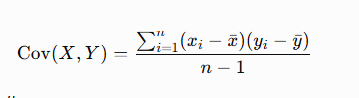
Concordance Correlation Coefficient，一致性相关系数

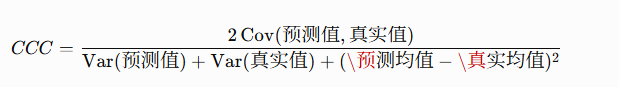

分母prediction_variance + label_variance比较预测值和真实值的波动大小是否接近。(prediction_mean - label_mean) ** 2惩罚预测均值和真实均值之间的偏差。
ccc 检查趋势是否一致，还检查均值是否接近，波动大小是否接近，数值变化方向是否一致
CCC 接近 1：预测和真实值高度一致
CCC 接近 0：一致性较弱
CCC 小于 0：预测和真实值可能呈反向关系

1. 数值变化方向是否一致：covariance
2. 均值是否接近：(prediction_mean - label_mean) ** 2
3. 波动大小是否接近：两个 variance，prediction_variance表示预测值的分散或波动程度；

In [69]:
def concordance_correlation_coefficient(
        predictions,labels
):
    predictions=predictions.float()
    labels=labels.float()

    prediction_mean=predictions.mean()
    label_mean=labels.mean()

    prediction_variance=predictions.var(correction=1)

    label_variance=labels.var(correction=1)

    prediction_centered=predictions-prediction_mean

    label_centered=labels-label_mean

    covariance=(prediction_centered*label_centered).sum()/(predictions.numel() - 1)

    numerator=2*covariance

    denominator=(
        prediction_variance+label_variance+(prediction_mean-label_mean)**2+EPS
    )

    ccc=numerator/denominator

    return ccc

In [70]:
toy_predictions_float = (
    toy_predictions.float()
)

toy_labels_float = (
    toy_true_labels.float()
)

toy_accuracy = (
    toy_predictions
    == toy_true_labels
).float().mean()

toy_ccc = (
    concordance_correlation_coefficient(
        toy_predictions_float,
        toy_labels_float,
    )
)

toy_rmse = torch.sqrt(
    F.mse_loss(
        toy_predictions_float,
        toy_labels_float,
    )
)

toy_mae = F.l1_loss(
    toy_predictions_float,
    toy_labels_float,
)

print("Accuracy：", toy_accuracy.item())
print("CCC：", toy_ccc.item())
print("RMSE：", toy_rmse.item())
print("MAE：", toy_mae.item())

Accuracy： 0.6000000238418579
CCC： 0.6905709505081177
RMSE： 0.8366600275039673
MAE： 0.5


In [ ]:
for i in range(10):
    f"x{i}"=torch.arange(10)